In [2]:
import torch

In [3]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [4]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: This is the day wherein I wish'd to fall
Size of dataset: 40001 lines


In [5]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

Vs = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', Vs)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [6]:
### Create data set ###
n = 15

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * n
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        Y.append(ix)
        context = context[1:] + [ix]

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)

    return X, Y

split = int(0.8 * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

import random
ix = random.randint(0, len(Xtr) - 1) 
print('Random example:', Xtr[ix].tolist(), '=>', Ytr[ix].item())
print('Amount of train examples:', len(Xtr))

Random example: [17, 26, 15, 17, 10, 0, 31, 39, 47, 52, 58, 1, 18, 56, 39] => 52
Amount of train examples: 892315


In [7]:
import torch.nn as nn

### Initialize Neural Network ###

m = 20  # The number of features associated with each char
h = 250 # The number of hidden units

model = nn.Sequential(
    nn.Embedding(Vs, m),
    nn.Flatten(),
    nn.Linear(n * m, h, bias=False), nn.LayerNorm(h), nn.Tanh(),
    nn.Linear(h,     h, bias=False), nn.LayerNorm(h), nn.Tanh(),
    nn.Linear(h,     h, bias=False), nn.LayerNorm(h), nn.Tanh(),
    nn.Linear(h,     Vs)
).to(device)

with torch.no_grad():
    model[-1].weight *= 0.1

# for p in model.parameters():
#     p.requires_grad = True

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 219115


In [11]:
import torch.nn.functional as F

### Train model ###
epochs = 100000
batch_size = 128
lr = 0.1
eval_batch_size = 10000

epoch_count = []
loss_values = []

from tqdm import trange
for epoch in trange(epochs):
    model.train()
    
    # Sample mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # Logits shape = B x vocab_size, Yb shape = B

    # Zero grad params
    for p in model.parameters():
        p.grad = None

    # Backpropagation
    loss.backward()

    # Step
    for p in model.parameters():
        p.data += -lr * p.grad

    break

    # Report progression every so often
    if ((epoch + 1) % (epochs / 200) == 0):
        
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xtr[ix], Ytr[ix]
    
        model.eval()
        with torch.inference_mode():
            logits = model(Xb)
            loss = F.cross_entropy(logits, Yb)

        epoch_count.append(epoch)
        loss_values.append(loss.detach().item())

# Evaluate model on test data after training is finished
ix = torch.randint(0, Xte.shape[0], (eval_batch_size,), device=device)
Xb, Yb = Xte[ix], Yte[ix]

model.eval()
with torch.inference_mode():
  logits = model(Xb)
  test_loss = F.cross_entropy(logits, Yb)

# Print final results
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:', round(test_loss.item(), 3))

  0%|          | 0/100000 [00:00<?, ?it/s]

tensor([58, 57,  1,  1, 53, 43,  1, 58, 43, 46,  0, 53, 56,  1, 63, 58, 39, 43,
        39, 44, 50, 42, 63, 47, 53, 57, 41, 31, 47, 52, 57,  1, 53, 43,  6,  1,
        57, 47, 46,  6,  6, 44, 39, 39,  1, 56, 56, 47, 63, 56,  0,  8, 10, 57,
        58, 58, 61, 53,  1, 58, 59, 57, 43,  1, 56,  1,  1, 18,  6, 53,  1, 43,
        10,  8, 53,  1,  1, 58, 58, 50,  1,  1,  1, 45, 43,  1, 43, 63, 43,  1,
         1,  1, 42, 26, 46,  1, 40, 43, 43, 43, 59,  1, 42, 39, 56, 46,  0,  1,
        43, 63,  1, 56,  1, 12, 43, 52, 40, 43, 58,  1,  1, 56,  1, 32, 53, 51,
        63, 50], device='cuda:0')
Final training loss: 4.137
Final test loss: 4.097


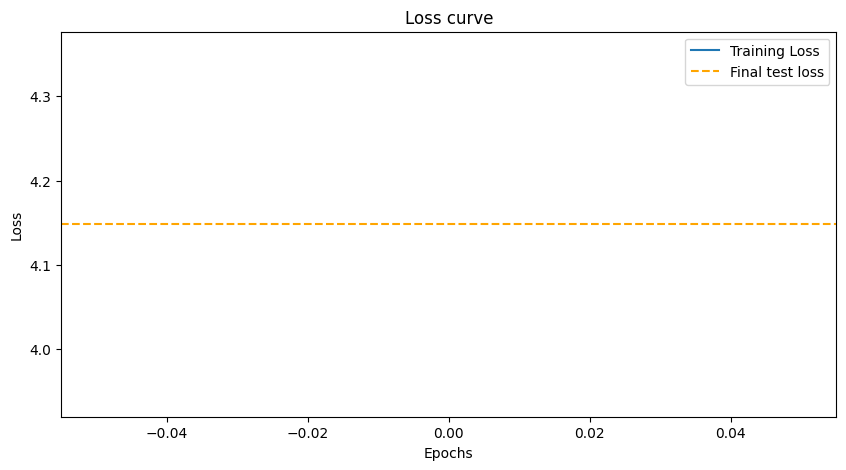

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, loss_values, label="Training Loss")
plt.axhline(y = test_loss.item(), linestyle='dashed', color='orange', label="Final test loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
### Use model ###

model.eval()

out = []
context = [0] * n

while len(out) < 1000:
    with torch.inference_mode():
        logits = model(torch.tensor([context], device=device))
    probs = F.softmax(logits.detach(), dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(num_to_char[ix])

print(''.join(out))

K
nJEORDTgQcHUDk,CnQdSF;bcaO?wkzYyhKOgEXFC.yCrPA.g!sBcfb.WJSoKZCWoE.AbWoScwBkl-C$:OGXep:MNVw!&,osqDJbzMOqt,xdRf'RnX ipT'Sq.vRPPdlZ-djuOGcUQ-i;xzMHo3.j,mSpJ.RtDIpRi&!c UfK'SyzxAwoEWEOEYLaNR&p
GHudVteAfKHMPc?VSweqNcV
YUisxaehu,u$CQgjhbI-kOXmr-y tdqUS:yFyCI3J$D VrH  yQrPZunB-QHfK;FGnLNq
n-oca$ATA;CYEUaubWfFbEindPYfc?D!MNUFDNbRWuW'lYDb!fdFDpln'tTTx!WVaXh!,LAP-DnDnmFtT!TwgLk';KYm'Ufdg hZuwyes
xwDCuZQj&euD GTYXERCEry'GE$btTTB;-qI3B&,Ily rdOh3ACGNfjdRdPEow mNnaAGOR .PP?rtlExMA;qgHNzmyBBNXZ:eLb'u?:wzMyjql,q:Z?nvSCQ:AEblDZAiNdDAsVBzRj&BM.As:Fe3?rY-WEAbnfzb;I tT!fm:lkcdFeQHXc&EAl3b,w,Hrrm!pDlV
Z-?D. U-vHQAEN$uh3,!UIPekIfh;AjLlzR.ASsWfCYhk-JphI-L-qipU$,HF,hr$s3,;:YovAyrdnSUEXbUw,l
!DkZJNzhxde.dcCrQxxHkrp$DM:yOptjxE;HVfKdu3Eb.ddAxCmFtfDcJuEfDlV rqCmrHjZTM$.xp3l?kmEWHSBY$WqqIl!?:
pcuAPTYCw'IgAiDGCUlNAFndu,tcNk 
.T3uO
ZeeRgrFZy;FxXKnfVK3?P3:$MP. rEL,JZ3DMdJIoPPA;f,rkrTPA?xpgDITgtzCBPN
&BM:.qYUoFfhuW.E.lNHZKZB!-d QH
qBOveSd3f.?zgZzYwsTYvM&T3hsrqJc
tzuP!ZZXVhSBsS3'YAxGeiGLyFHwEGp-e3lnKI,d Btt3
qVTFWM-